# 04 — Chemistry-only: normalized removal drivers (full timeline)

**Goal:** Train **low-parameter** models on the full chemistry timeline (no 16S), using **normalized removal** so small differences (e.g. 2010 median ~98.8% vs recent ~99.8%) are visible to the model.

| | |
|--|--|
| **Y** | `removal_3310_3340` (raw + z-scored); optional `log10(dioxane_3340)` |
| **X** | Shortlist of influent/blend (3310/3320) chemistry + field |
| **Excluded from X** | all `*_3340` (effluent / leakage) |
| **Grain** | one row = one sampling date |
| **n** | ~1,076 dates with removal (2004–2025) |
| **Validation** | time split (train ≤2016, test ≥2017) + within-era checks |

**Inputs:** `data/processed/bts_chemistry_field_by_date.csv` (from Notebook 01)  
**Outputs:** coefficient tables + figures under `data/processed/analysis_results/`

**Caveat:** Removal is almost always high (no true failure labels). This studies *relative* underperformance, especially 2010–2013, not success-vs-failure classification.


## Step 1 — Setup


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_theme(style="whitegrid")


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "processed").is_dir():
            return candidate
    raise FileNotFoundError("Could not find project root.")


def is_effluent_col(col: str) -> bool:
    return str(col).endswith("_3340")


PROJECT_ROOT = find_project_root()
PROC = PROJECT_ROOT / "data/processed"
CHEM_PATH = PROC / "bts_chemistry_field_by_date.csv"
OUT_DIR = PROC / "analysis_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

Y_COL = "removal_3310_3340"
EFFLUENT_COL = "dioxane_3340"
TRAIN_END = "2016-12-31"  # train ≤ this date; test after

SHORTLIST = [
    "dioxane_3310",
    "dioxane_3320",
    "pH_3310",
    "pH_3320",
    "temp_3310",
    "temp_3320",
    "field_nitrogen_ammonia_3310",
    "field_conductivity_3310",
    "field_total_suspended_solids_3310",
    "sr_tetrahydrofuran_3310",
    "sr_tetrahydrofuran_3320",
    "sr_benzene_3310",
    "sr_chloroform_3310",
    "sr_nitrogen_nitrate_plus_nitrite_3310",
    "sr_nitrogen_nitrite_3310",
    "sr_total_phosphorus_3320",
]

if not CHEM_PATH.exists():
    raise FileNotFoundError(f"Run Notebook 01 first. Missing: {CHEM_PATH}")

print("Project root:", PROJECT_ROOT)
print("Chemistry:", CHEM_PATH)


Matplotlib is building the font cache; this may take a moment.


Project root: /Users/shaivikoul/Documents/DIOPredict LOWRY
Chemistry: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/bts_chemistry_field_by_date.csv


## Step 2 — Load chemistry timeline & define X / Y


In [ ]:
df = pd.read_csv(CHEM_PATH, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

# Keep rows where plant-level removal can be computed
df = df.dropna(subset=[Y_COL]).copy()
df["year"] = df["date"].dt.year
df["era"] = np.where(
    df["date"] < "2010-01-01",
    "2004-2009",
    np.where(
        df["date"] < "2014-01-01",
        "2010-2013",
        np.where(df["date"] < "2017-01-01", "2014-2016", "2017-2025"),
    ),
)

# Normalized Y (global z-score) —  suggestion for low variation
y_mean = df[Y_COL].mean()
y_std = df[Y_COL].std(ddof=0)
df["removal_z"] = (df[Y_COL] - y_mean) / y_std

# Blend→effluent Y (3320 includes recycle; closer to reactor performance)
# Not in Notebook 01 CSV — compute here from dioxane_3320 / dioxane_3340
Y_COL_3320 = "removal_3320_3340"
df[Y_COL_3320] = (
    (df["dioxane_3320"] - df[EFFLUENT_COL]) / df["dioxane_3320"] * 100
)
n_3320 = df[Y_COL_3320].notna().sum()
y3320_mean = df[Y_COL_3320].mean()
y3320_std = df[Y_COL_3320].std(ddof=0)
df["removal_3320_z"] = (df[Y_COL_3320] - y3320_mean) / y3320_std

# Alternate Y with more dynamic range
df["log10_effluent"] = np.log10(df[EFFLUENT_COL].clip(lower=1e-3))

X_COLS = [c for c in SHORTLIST if c in df.columns and not is_effluent_col(c)]
missing_short = [c for c in SHORTLIST if c not in df.columns]
if missing_short:
    print("Shortlist cols not in CSV (skipped):", missing_short)

print(f"Rows with removal Y: {len(df)}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"X features ({len(X_COLS)}): {X_COLS}")
print(f"\nY 3310→3340: mean={y_mean:.3f}  std={y_std:.3f}  min={df[Y_COL].min():.2f}  max={df[Y_COL].max():.2f}")
print(f"Y 3320→3340: n={n_3320}  mean={y3320_mean:.3f}  std={y3320_std:.3f}  min={df[Y_COL_3320].min():.2f}  max={df[Y_COL_3320].max():.2f}")
print("\nCoverage of X (non-null %):")
for c in X_COLS:
    pct = 100 * df[c].notna().mean()
    print(f"  {c:45s} {pct:5.1f}%")

print("\nRemoval 3310→3340 by era:")
print(
    df.groupby("era")[Y_COL]
    .agg(n="count", median="median", mean="mean", std="std", min="min")
    .round(3)
    .to_string()
)
print("\nRemoval 3320→3340 by era:")
print(
    df.groupby("era")[Y_COL_3320]
    .agg(n="count", median="median", mean="mean", std="std", min="min")
    .round(3)
    .to_string()
)


Rows with removal Y: 1076
Date range: 2004-05-05 → 2025-09-02
X features (16): ['dioxane_3310', 'dioxane_3320', 'pH_3310', 'pH_3320', 'temp_3310', 'temp_3320', 'field_nitrogen_ammonia_3310', 'field_conductivity_3310', 'field_total_suspended_solids_3310', 'sr_tetrahydrofuran_3310', 'sr_tetrahydrofuran_3320', 'sr_benzene_3310', 'sr_chloroform_3310', 'sr_nitrogen_nitrate_plus_nitrite_3310', 'sr_nitrogen_nitrite_3310', 'sr_total_phosphorus_3320']

Y 3310→3340: mean=99.595  std=0.532  min=91.69  max=100.00
Y 3320→3340: n=1075  mean=96.704  std=3.841  min=36.36  max=100.00

Coverage of X (non-null %):
  dioxane_3310                                  100.0%
  dioxane_3320                                   99.9%
  pH_3310                                        67.8%
  pH_3320                                        97.1%
  temp_3310                                      67.8%
  temp_3320                                      97.1%
  field_nitrogen_ammonia_3310                    67.8%
  field_cond

## Step 3 — Train low-parameter models (Ridge + LASSO)

- Impute missing X with **median** (fit on train only via Pipeline).
- **StandardScaler** on X.
- **Y variants:** raw removal %, z-scored removal, log10 effluent.
- **Time split:** train dates ≤ 2016-12-31, test ≥ 2017-01-01 (respects chronology; soft era 2010–2013 is in train).


In [3]:
def fit_eval(X_train, y_train, X_test, y_test, model_name="ridge"):
    if model_name == "ridge":
        est = RidgeCV(alphas=np.logspace(-3, 3, 25))
    elif model_name == "lasso":
        est = LassoCV(alphas=np.logspace(-4, 1, 40), max_iter=10000, cv=5, random_state=0)
    else:
        raise ValueError(model_name)

    pipe = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", est),
        ]
    )
    pipe.fit(X_train, y_train)
    pred_tr = pipe.predict(X_train)
    pred_te = pipe.predict(X_test)
    metrics = {
        "model": model_name,
        "n_train": len(y_train),
        "n_test": len(y_test),
        "r2_train": r2_score(y_train, pred_tr),
        "r2_test": r2_score(y_test, pred_te),
        "mae_train": mean_absolute_error(y_train, pred_tr),
        "mae_test": mean_absolute_error(y_test, pred_te),
    }
    coefs = pd.Series(pipe.named_steps["model"].coef_, index=X_COLS).sort_values(
        key=np.abs, ascending=False
    )
    return pipe, metrics, coefs, pred_te


train = df[df["date"] <= TRAIN_END].copy()
test = df[df["date"] > TRAIN_END].copy()
print(f"Train ≤ {TRAIN_END}: n={len(train)}  |  Test > {TRAIN_END}: n={len(test)}")

targets = {
    "removal_raw": Y_COL,
    "removal_z": "removal_z",
    "log10_effluent": "log10_effluent",
}

all_metrics = []
coef_tables = {}
predictions = {}

for y_name, y_col in targets.items():
    # drop rows missing this Y (effluent can be missing rarely)
    tr = train.dropna(subset=[y_col])
    te = test.dropna(subset=[y_col])
    Xtr, ytr = tr[X_COLS], tr[y_col].values
    Xte, yte = te[X_COLS], te[y_col].values

    print(f"\n===== Target: {y_name} ({y_col}) =====")
    for model_name in ("ridge", "lasso"):
        pipe, metrics, coefs, pred_te = fit_eval(Xtr, ytr, Xte, yte, model_name=model_name)
        metrics["target"] = y_name
        all_metrics.append(metrics)
        coef_tables[(y_name, model_name)] = coefs
        predictions[(y_name, model_name)] = (te["date"].values, yte, pred_te)
        print(
            f"  {model_name:6s}  R² train={metrics['r2_train']:.3f}  "
            f"R² test={metrics['r2_test']:.3f}  "
            f"MAE test={metrics['mae_test']:.4f}"
        )
        print("  top |coef|:")
        print(coefs.head(8).to_string())

metrics_df = pd.DataFrame(all_metrics)[
    ["target", "model", "n_train", "n_test", "r2_train", "r2_test", "mae_train", "mae_test"]
]
metrics_path = OUT_DIR / "nb04_time_split_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
print(f"\nSaved metrics: {metrics_path}")
print(metrics_df.round(4).to_string(index=False))


Train ≤ 2016-12-31: n=627  |  Test > 2016-12-31: n=449

===== Target: removal_raw (removal_3310_3340) =====
  ridge   R² train=0.194  R² test=-0.737  MAE test=0.2002
  top |coef|:
sr_nitrogen_nitrate_plus_nitrite_3310    0.119228
dioxane_3310                             0.094576
sr_nitrogen_nitrite_3310                 0.061623
sr_tetrahydrofuran_3320                  0.053653
sr_total_phosphorus_3320                 0.051251
sr_tetrahydrofuran_3310                  0.045960
pH_3310                                 -0.038878
field_conductivity_3310                  0.034226
  lasso   R² train=0.176  R² test=-0.838  MAE test=0.2327
  top |coef|:
sr_nitrogen_nitrate_plus_nitrite_3310    0.146540
dioxane_3310                             0.088990
sr_nitrogen_nitrite_3310                 0.046867
sr_tetrahydrofuran_3310                  0.046234
sr_total_phosphorus_3320                 0.028486
sr_tetrahydrofuran_3320                  0.015828
pH_3310                                 -0.01235

## Step 4 — Plots (test-set fit + LASSO coefficients for z-scored removal)


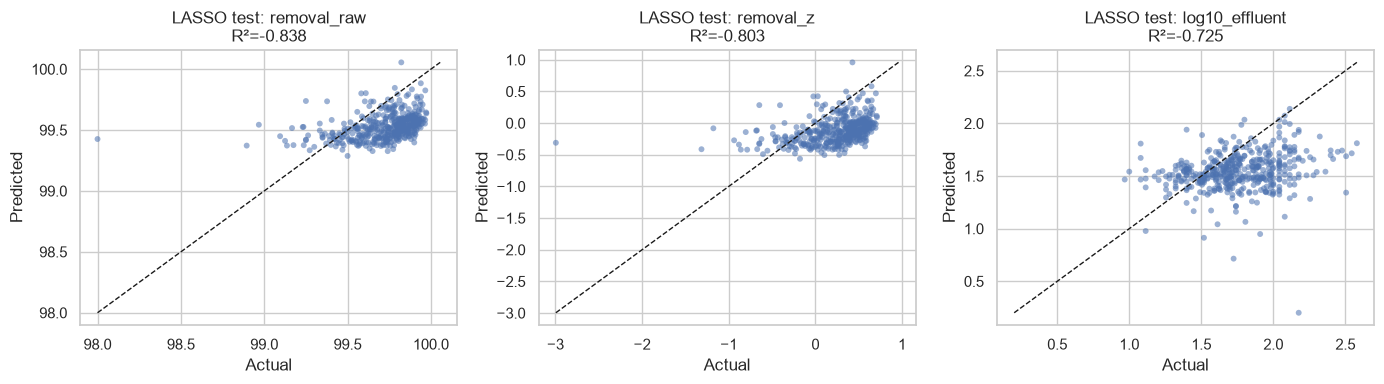

Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb04_pred_vs_actual_test.png


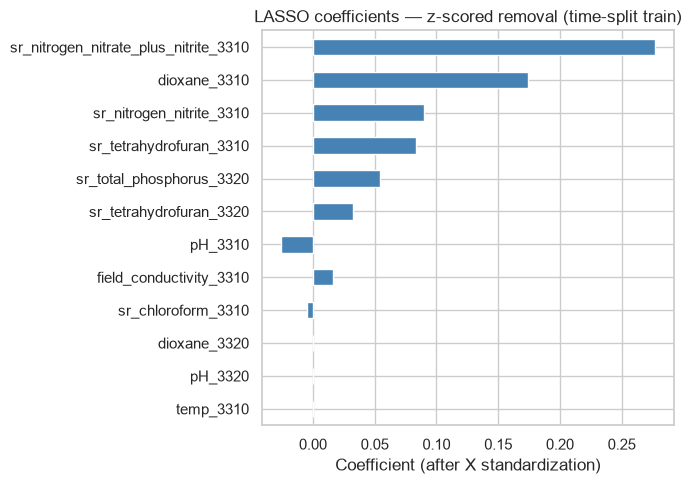

Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb04_lasso_coefs_removal_z.png
Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb04_coefficients.csv


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, y_name in zip(axes, ["removal_raw", "removal_z", "log10_effluent"]):
    dates, y_true, y_pred = predictions[(y_name, "lasso")]
    ax.scatter(y_true, y_pred, s=18, alpha=0.55, edgecolor="none")
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    r2 = metrics_df.query("target == @y_name and model == 'lasso'")["r2_test"].iloc[0]
    ax.set_title(f"LASSO test: {y_name}\nR²={r2:.3f}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

plt.tight_layout()
fig_path = OUT_DIR / "nb04_pred_vs_actual_test.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

coefs_z = coef_tables[("removal_z", "lasso")]
fig, ax = plt.subplots(figsize=(7, 5))
coefs_z.head(12).iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("LASSO coefficients — z-scored removal (time-split train)")
ax.set_xlabel("Coefficient (after X standardization)")
plt.tight_layout()
coef_fig = OUT_DIR / "nb04_lasso_coefs_removal_z.png"
plt.savefig(coef_fig, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", coef_fig)

# Export coefficients for all targets
coef_rows = []
for (y_name, model_name), coefs in coef_tables.items():
    for feat, val in coefs.items():
        coef_rows.append({"target": y_name, "model": model_name, "feature": feat, "coef": val})
coef_df = pd.DataFrame(coef_rows)
coef_path = OUT_DIR / "nb04_coefficients.csv"
coef_df.to_csv(coef_path, index=False)
print("Saved:", coef_path)


## Step 5 — Era sensitivity (does the soft era drive the signal?)

Fit LASSO on z-scored removal **within** eras, using a random 70/30 split *inside* each era (small check only — eras are shorter).


In [5]:
from sklearn.model_selection import train_test_split

era_rows = []
for era, sub in df.groupby("era"):
    sub = sub.dropna(subset=["removal_z"])
    if len(sub) < 40:
        print(f"Skip {era}: n={len(sub)}")
        continue
    # z-score Y within era so we ask: what explains relative dips *inside* this period?
    sub = sub.copy()
    sub["removal_z_era"] = (sub[Y_COL] - sub[Y_COL].mean()) / sub[Y_COL].std(ddof=0)
    tr, te = train_test_split(sub, test_size=0.3, random_state=0)
    pipe, metrics, coefs, _ = fit_eval(
        tr[X_COLS], tr["removal_z_era"].values, te[X_COLS], te["removal_z_era"].values, "lasso"
    )
    metrics["era"] = era
    metrics["target"] = "removal_z_within_era"
    era_rows.append(metrics)
    print(f"{era:12s} n={len(sub):4d}  R² test={metrics['r2_test']:.3f}  top: {coefs.head(3).index.tolist()}")

era_df = pd.DataFrame(era_rows)
era_path = OUT_DIR / "nb04_era_sensitivity_metrics.csv"
era_df.to_csv(era_path, index=False)
print("\nSaved:", era_path)
print(era_df[["era", "n_train", "n_test", "r2_test", "mae_test"]].round(3).to_string(index=False))


2004-2009    n= 265  R² test=0.003  top: ['temp_3320', 'sr_tetrahydrofuran_3310', 'sr_nitrogen_nitrite_3310']
2010-2013    n= 207  R² test=-0.060  top: ['temp_3310', 'sr_chloroform_3310', 'dioxane_3310']
2014-2016    n= 155  R² test=0.074  top: ['field_conductivity_3310', 'dioxane_3310', 'temp_3320']
2017-2025    n= 449  R² test=0.102  top: ['dioxane_3310', 'sr_tetrahydrofuran_3310', 'sr_tetrahydrofuran_3320']

Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb04_era_sensitivity_metrics.csv
      era  n_train  n_test  r2_test  mae_test
2004-2009      185      80    0.003     0.379
2010-2013      144      63   -0.060     0.538
2014-2016      108      47    0.074     0.615
2017-2025      314     135    0.102     0.618


## Step 6 — Takeaways (from first run)

| Target | Model | R² train (≤2016) | R² test (≥2017) | Note |
|--------|-------|------------------|-----------------|------|
| removal % | Ridge | ~0.19 | **−0.74** | Weak in-sample; **does not transfer** to recent years |
| removal z-scored | Ridge/LASSO | ~0.19 | **−0.74 / −0.80** | Same R² as raw (linear models); scaling alone ≠ new signal |
| log10 effluent | LASSO | ~0.63 | **−0.73** | Stronger fit on train; still fails chronological test |

**What this means**
1. There is **some** association in the historical train window (nitrogen species, influent dioxane, THF appear in top coefficients).
2. Patterns learned on ≤2016 **do not predict** 2017–2025 well — the plant regime may have changed, or associations are unstable.
3. **Z-scoring Y does not fix** out-of-sample failure (as expected for linear models: R² is scale-invariant).
4. Within-era LASSO R² is near 0–0.10 — even soft era 2010–2013 has little linear signal for relative dips.
5. Next levers: feature pruning, nonlinear models (careful), ops covariates (flow if available), or redefine the question (e.g. classify elevated effluent days) — not more aggressive Y rescaling alone.

Coefficients / metrics saved under `data/processed/analysis_results/nb04_*`.
